<a href="https://colab.research.google.com/github/eduardofmj97/EBAC/blob/main/Profissao_Cientista_de_Dados_M19_Pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

Os dados são criados a seguir:

In [4]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




O teste en questão será unilateral à direita, uma vez que queremos avaliar se a média da estratégia B é maior do que da estratégia A (media A < media B), ou seja, se  a Hipotese 1 é verdadeira, rejeitando a Hipotese 0.:

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [5]:
media_A = np.mean(amostra_estrategia_A)
variancia_A = np.var(amostra_estrategia_A)

media_B = np.mean(amostra_estrategia_B)
variancia_B = np.var(amostra_estrategia_B)

print(f"Média da Estratégia A: {media_A:.2f}")
print(f"Variância da Estratégia A: {variancia_A:.2f}")
print(f"\nMédia da Estratégia B: {media_B:.2f}")
print(f"Variância da Estratégia B: {variancia_B:.2f}")


Média da Estratégia A: 71.41
Variância da Estratégia A: 126.68

Média da Estratégia B: 74.75
Variância da Estratégia B: 108.26


Podemos notar que a estratégia B tem uma média maior do que a A, possivelmente indicando uma melhor performance dos alunos, além da estratégia B ter uma menor variância, o que indica maior consistência e menor dispersão dos dados da amostra B comparado com a amostra A.

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [8]:
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

# Calculando o erro padrão combinado
std_err_diff = np.sqrt((variancia_A / n_A) + (variancia_B / n_B))

# Calculando a estatística Z
z_statistic = (media_B - media_A) / std_err_diff

# Calculando o p-valor para um teste unilateral à direita (H1: media_B > media_A)
p_value = 1 - stats.norm.cdf(z_statistic)

alpha = 0.05 # Nível de significância

print(f"Estatística Z: {z_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"\nCom um p-valor ({p_value:.4f}) menor que o nível de significância alpha ({alpha}), rejeitamos a hipótese nula.")
    print("Isso sugere que há evidências estatísticas de que a média das notas da Estratégia B é significativamente maior do que a média das notas da Estratégia A.")
else:
    print(f"\nCom um p-valor ({p_value:.4f}) maior que o nível de significância alpha ({alpha}), não rejeitamos a hipótese nula.")
    print("Isso sugere que não há evidências estatísticas suficientes para afirmar que a média das notas da Estratégia B é significativamente maior do que a média das notas da Estratégia A.")


Estatística Z: 1.5422
P-value: 0.0615

Com um p-valor (0.0615) maior que o nível de significância alpha (0.05), não rejeitamos a hipótese nula.
Isso sugere que não há evidências estatísticas suficientes para afirmar que a média das notas da Estratégia B é significativamente maior do que a média das notas da Estratégia A.


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

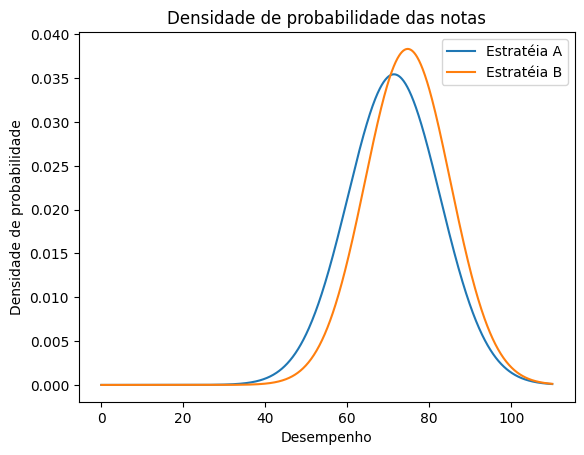

In [16]:
desvio_padrao_A = np.std(amostra_estrategia_A)
desvio_padrao_B = np.std(amostra_estrategia_B)

x = np.linspace(0.03, 110, 1000)

plt.plot(x, norm.pdf(x, media_A, desvio_padrao_A), label='Estratéia A')
plt.plot(x, norm.pdf(x, media_B, desvio_padrao_B), label='Estratéia B')
plt.xlabel('Desempenho')
plt.ylabel('Densidade de probabilidade')
plt.title('Densidade de probabilidade das notas')
plt.legend()
plt.show()

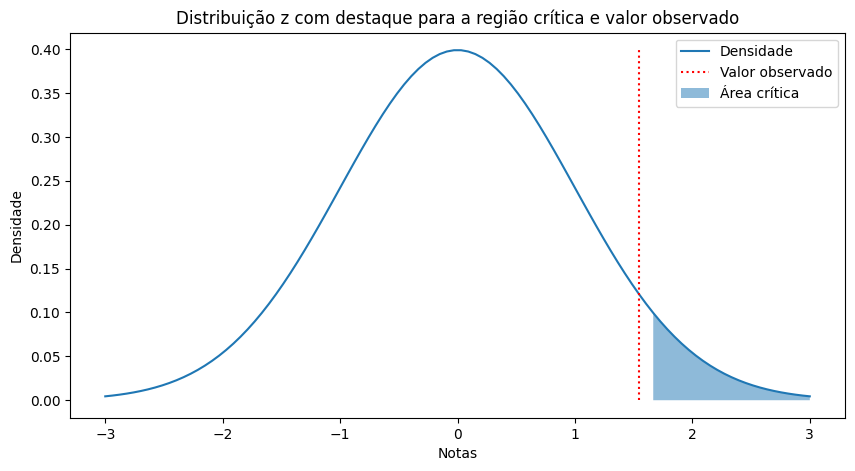

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

mu = 0
variance = 1
sigma = variance**.5

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = norm.pdf(x, mu, sigma)

low = norm.ppf(.95)

high = np.inf

ax.plot(x, y, label='Densidade')
ax.vlines(x=[z_statistic], ymin=0, ymax=y.max(), colors='r', linestyles='dotted', label='Valor observado')

plt.fill_between(x, y, where=(low < x) & (x < high), alpha = .5, label='Área crítica')

plt.legend()
plt.xlabel('Notas')
plt.ylabel('Densidade')
plt.title('Distribuição z com destaque para a região crítica e valor observado')
plt.show()

Agora podemos notar visualmente que o valor do p-value observado através da análise está antes da área crítica, ou seja, não podemos rejeitar a hipótese nula.